# Exploratory Data Analysis(EDA)

Company Accounts publically available from Companies House https://download.companieshouse.gov.uk/Accounts_Monthly_Data-November2025.zip
298,461 Accounts
18.53GB uncompressed

This is a living document and has been updated after full itterations of the CRISP-DM cycle, taking into account learning at later stages such as reviewing errors from ML predictions


In [ ]:
from pathlib import Path, PurePosixPath
from zipfile import ZipFile
from typing import Sequence
import random
import webbrowser

from bs4 import BeautifulSoup
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import powerlaw
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import LabelEncoder, Normalizer
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer


from ixbrl_ai.display import heading, display_wide

from ixbrl_ai.sample import DataSample

In [ ]:
# Global definitions
MAX_WORDS = 15
SEED = 42
# High so that 1% subset has enough examples with cross validation 3
MIN_EXAMPLES = 350 


In [ ]:
# Set random seed
np.random.seed(SEED)
random.seed(SEED)


# 1. HTML Accounts

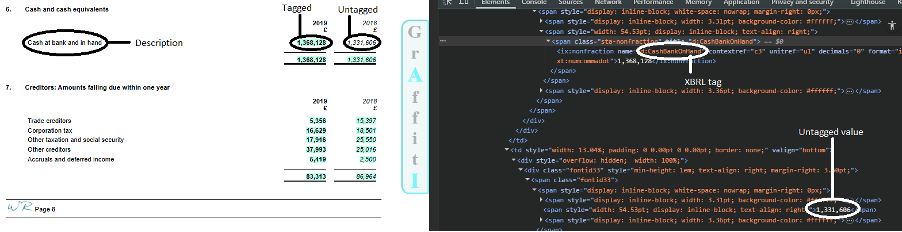
Figure 1 Example of iXBRL document, open with Graffiti viewer(www.stechanalytics.com) with the underlying html shown on the right. Showing that XBRL tagged items are in an ix:nonfraction node, with a named element(xbrl concept), but untagged items are in standard html nodes such as span nodes.

It is easy to extract iXBRL tagged item and there are fixed taxonomies that clearly categorise what the value is. e.g. FRC taxonomies https://www.frc.org.uk/library/standards-codes-policy/accounting-and-reporting/frc-taxonomies/

It is possible to extract the untagged data.



In [ ]:
def parse_html_file(file_path: Path) -> BeautifulSoup:
    """ Parses html file with BeautifulSoup

    Args:
        file_path (Path): Path to the file

    Returns:
        BeautifulSoup: BeautifulSoup object containing the parsed HTML content
    """
    
    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]
    html_content = None
    
    for encoding in encodings:
        try:
            with open(file=file_path, mode="r", encoding=encoding) as f:
                html_content = f.read()
            break
        except UnicodeDecodeError:
            continue
    
    if html_content is None:
        print(f"Warning: Could not read file {file_path}")
        return BeautifulSoup(markup="", features="html.parser")

    return BeautifulSoup(markup=html_content, features="html.parser")

## 1.1 Load Sample of html accounts

In [ ]:
path_to_data= Path('~/Downloads/Accounts_Monthly_Data-November2025').expanduser()
files = [file for file in path_to_data.iterdir() if file.is_file()]

In [ ]:
suffixes= [file.suffix for file in files]

zip_index = suffixes.index(".zip")

with ZipFile(files[zip_index]) as z:
    zip_suffixes = [PurePosixPath(name).suffix for name in z.namelist()]


set(suffixes + zip_suffixes)

In [ ]:
100 * np.sum(np.array(suffixes) == ".zip")/len(suffixes)

The main files of interest are html and xhtml formats. While html and xhtml are very similar and most code should work across both it should be noted that sometimes they will behave differently(depending on language and packages).

- ESEF or UKSEF packages the files into a zip archive, but the underlying format inside them is xhtml. 
- Only 0.05% of the returns are in a zip, so these notebooks won't extract or use them. 



In [ ]:
sample_size = 1000
no_tables_html= None
many_tables_html= None

document_htmls = [parse_html_file(file_path=file) for file in files[0:sample_size]]
tables = [len(document_html.find_all(name="table")) for document_html in document_htmls]
table_lengths = np.array(tables)

In [ ]:
def view_html(files: Sequence[Path], index: int) -> None:
    """ Shows html in viewer(Positron) not sure if it work on other IDEs

    Args:
        index (int): index
    """
    path = files[index]
    webbrowser.open(url=path.as_uri())

## 1.2 HTML table nodes

In [ ]:
display(f"Docs with table nodes: {len(table_lengths) - np.sum(table_lengths == 0)} out of {len(table_lengths)}")
# First document with 11 tables
view_html(files=files, index=np.flatnonzero(table_lengths == 11)[0])

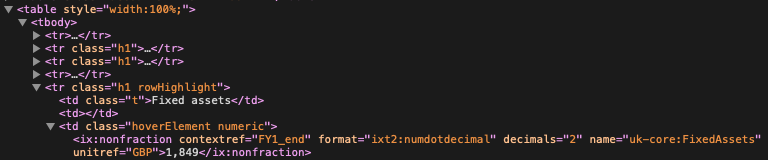

- Most accounts ~85% use html table nodes. 
- The relevant iXBRL data have their own node types like ix:nonfraction, and can be parsed using something like Beautiful soup. 
- The description is in table and could also be extracted by parsing the table node. 


## 1.3 No table nodes

In [ ]:
display(f"Docs without any table nodes {np.sum(table_lengths == 0)} out of {len(table_lengths)}")
view_html(files=files, index=np.flatnonzero(table_lengths == 0)[4])


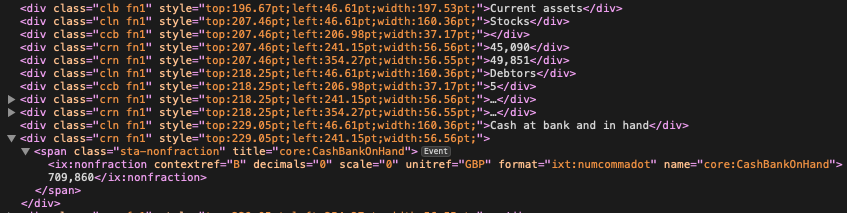

- Some accounts ~15% don't use html table nodes.
- The iXBRL data can be easily extracted, but untagged items like the descriptions and values can be hard to extract. 
- To extract this data you have to write bespoke code to recreate the tables based on the nodes' positions. 
- I have written R code internally that can also extract the tabula data from these documents that don't use table nodes.  
- Since this is a minority group and there is a sufficiently large population, these notebooks won't extract data from these document. 


## 1.4 Structure of data and features

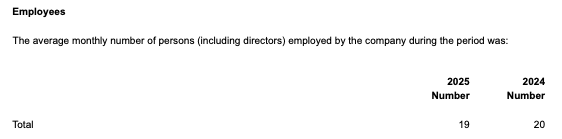

Here we have.   
Table name: Employees.   
Description: Total.    
Headings: "2025 Number" and "2024 Number".  

- Initial versions just extracted and used the descriptions for the ML. But here you can see that the description(Total) doesn't tell you enough information about what the value is, you also need the headings and table name.  
- The actual value wouldn't be a great feature since number and text can vary greatly for the same class, but detecting the type of value could be useful, e.g. is it monetary or text. 
- I have written R code internally which uses all three and it improves ML.   
- These notebook just uses the description since it's the primary feature that is sufficient for most situations. The analysis and ML in these notebooks largerly follows over.  

# 2. EDA over extracted data
Data extracted from https://download.companieshouse.gov.uk/Accounts_Monthly_Data-November2025.zip.  
298,461 Accounts.  
Extracted using 00_ixbrl_data_extraction.ipynb.  


In [ ]:
dataset_pl = (
    pl.read_parquet("data/table_extracted_df_v5.parquet")
    .rename({"label": "xbrl_concept"})
    )

## 2.1 Describe Dataset

In [ ]:
def describe_dataset(dataset_pl: pl.DataFrame, description: str, label: str) -> dict:
    """ Describes the key characteristics of the dataset

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): The column name of the description feature
        label (str): The column name of the label

    Returns:
        dict: Key characteristics
    """
    description_col = dataset_pl[description]
    label_col = dataset_pl[label]
    word_count = description_col.str.count_matches(r"\w+").drop_nulls()
    word_mode = word_count.mode()
    word_mode_value = word_mode[0] if len(word_mode) > 0 else None

    stats = {
        "Shape": dataset_pl.shape,
        "Schema": dataset_pl.schema.items(),
        "Labels": label_col.n_unique(),
        "Unique descriptions": description_col.n_unique(),
        "Unique descriptions and labels": dataset_pl.select([description, label]).unique().height,  # n_unique doesn't give unique paris
        "Missing description values": description_col.null_count(),
        "Missing xbrl concepts": label_col.null_count(),
        "Mean description length(words)": word_count.mean(),
        "Mode description length(words)": word_mode_value,
        "Min description length(words)": word_count.min(),
        "Max description length(words)": word_count.max(),
        "Punctuation count(No words or letters)": description_col.str.contains(r"^[^\w\s]+$").fill_null(False).sum(),
    }
    heading("Descibe dataset")
    display(stats)
    return stats

description_stats = describe_dataset(dataset_pl, description="description", label="xbrl_concept")

- The main columns of interest are both strings
    - The description is inerently text based, where NLP could be useful.
    - The xbrl_concepts is a nominal category, so we could encode that to numeric labels. But the actual text could be useful in some preliminary analysis.  
- 2,857,703 lines of data across 956 labels, should provide enough training data but that will depend on the distribution across the labels.
- There are no null or completely missing data, but there are some descriptions that have no words. So that will need cleaning.
- 19,814 have no letters and are just punctuation and other characters. These need to be remove completely.
- Max word length of 1762 suggests an issue with extraction, the descriptions should normally just be a few words and a sentence at max.
- You have 266,278 unique descriptions mapped to 956 labels, which means multiple descriptions would be mapped to each label.
- There are 282,515 unique description and labels, vs 266,178 unique descriptions suggesting that there might be some descriptions mapped to different labels. - I'll look into that in a bit more detail further down


## 2.2 Frequency rank plot

In [ ]:
def frequency_rank_plot(
    dataset_pl: pl.DataFrame, description: str, label: str, max_rank: int = 3_000
) -> None:
    """Frequency rank plot

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): The column name of the description feature
        label (str): The column name of the label
        max_rank (int, optional): Cutoff number for how many tanks to show. Defaults to 3_000.
    """
    xbrl_concept_frequency = (
        dataset_pl.group_by(label)
        .len()
        .sort("len", descending=True)
        .get_column("len")
        .to_list()
    )
    description_frequency = (
        dataset_pl.group_by(description)
        .len()
        .sort("len", descending=True)
        .get_column("len")
        .to_list()
    )
    xbrl_concept_frequency = xbrl_concept_frequency[:max_rank]
    description_frequency = description_frequency[:max_rank]
    ax = sns.lineplot(
        y=description_frequency,
        x=np.arange(1, len(description_frequency) + 1),
        label=description,
    )
    sns.lineplot(
        y=xbrl_concept_frequency,
        x=np.arange(1, len(xbrl_concept_frequency) + 1),
        label=label,
        ax=ax,
    )
    ax.set_yscale("log")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Frequency(log scale)")
    ax.set_title(f"Rank Frequency (top {max_rank} ranks)")
    plt.show()


frequency_rank_plot(dataset_pl, description="description", label="xbrl_concept")

- Descriptions have a much longer tail
- The low ranked ixbrl concepts have a very high frequency of use.

## 2.3 Word count of discriptions distribution

In [ ]:
def plot_word_count(dataset_pl: pl.DataFrame, description: str) -> None:
    """Plots histogram of the word count

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): Column name of the description feature
    """
    word_count = dataset_pl[description].str.count_matches(r"\w+").drop_nulls()
    short_word_count = word_count.filter(word_count < 20)

    ax = sns.histplot(short_word_count, binwidth=1, binrange=(-0.5, 19.5))
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.set_title("Word Count Distribution (< 20 words)")
    ax.set_xlim(-0.5, 19.5)
    ax.set_xticks(range(0, 20, 1))
    plt.show()


plot_word_count(dataset_pl, "description")

- Very rough bell shap, with a long tail on the right
- Most descriptions have a word count between 1-9, with a mode of 2.

In [ ]:
def plot_word_distributions(dataset_pl: pl.DataFrame, description: str, label: str) -> None:
    """Plots boxplot of the 5 most common labels along with boxplot of everything

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): Column name of the description feature
        label (str): Column name of label
    """

    df = dataset_pl.with_columns(pl.col(description).str.count_matches(r"\w+").alias("word_count"))

    top_labels = df.group_by(label).len().sort("len", descending=True).head(5).get_column(label).to_list()

    all_df = df.select(pl.lit("All").alias(label), pl.col("word_count"))

    top_word_counts = (
        df.filter(pl.col(label).is_in(top_labels))
        .select(label, "word_count")
        .vstack(all_df)
        .filter(pl.col("word_count") < MAX_WORDS)
    )
    fig, ax1 = plt.subplots(figsize=(10, 10))
    sns.boxplot(y=label, x="word_count", data=top_word_counts.to_pandas(), ax=ax1)
    ax1.set_ylabel(label.replace("_", " "))
    ax1.set_xlabel("Word count")
    ax1.set_title(f"Boxplot of word distribution of 5 most common {label}s (word count < {MAX_WORDS})")

    plt.show()


plot_word_distributions(dataset_pl, description="description", label="xbrl_concept")

- Looking at the most 5 common xbrl concepts(label) used, they all have different distribution of the word count of their descriptions(feature).
- The interquartile ranges for them all are between two and seven. 

## 2.4 Samples of datasets

In [ ]:
def display_filtered_data(dataset_pl: pl.DataFrame, description: str) -> None:
    """Displays samples of datasets with various characteristics,
    head, uniuqe, no word math, long word match and between 9 and 18 words

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): Column name for description feature
    """

    df = dataset_pl.with_columns(
        pl.col(description).str.count_matches(r"\w+").alias("wc"),
        pl.col(description).hash(seed=SEED).alias("hash"),
    )
    heading("Data extracts")

    heading("Sample")
    display_wide(dataset_pl.drop("table_index"))

    heading("Unique and common descriptions")

    display_wide(
        df.group_by(description)
        .agg(pl.len().alias("n"), pl.col("hash").first())
        .sort(["n", "hash"])
        .drop("hash")
    )

    heading("No word matches")
    no_words_pl = df.filter(pl.col("wc") == 0).sort("hash").drop(["table_index", "hash"])
    sample_n = min(20, no_words_pl.height)
    if no_words_pl.height > 0:
        display(no_words_pl.sample(n=sample_n, seed=SEED, with_replacement=False))
    else:
        display("Nothing with no words")

    heading("Over 100 words")
    long_words_pl = df.filter(pl.col("wc") > 100).sort("hash").drop("hash")
    sample_n = min(20, long_words_pl.height)
    if long_words_pl.height > 0:
        display(
            long_words_pl.get_column(description)
            .sample(n=sample_n, seed=SEED, with_replacement=False)
            .to_list()
        )
    else:
        display("Nothing with over 100 words")

    def display_descriptions_of_length(str_length: int):
        heading(f"Showing descriptions of length {str_length}")
        filtered_pl = (
            df.filter(pl.col("wc") == str_length).get_column(description).unique(maintain_order=True)
        )

        sample_n = min(20, filtered_pl.len())
        if filtered_pl.len() == 0:
            display(f"Noting with {str_length} words")
            return

        display(filtered_pl.sample(n=sample_n, seed=SEED, with_replacement=False).to_list())

    for i in range(9, 18):
        display_descriptions_of_length(i)


display_filtered_data(dataset_pl, "description")

### Description
- Text feature.
- From these samples we can see there are various types of description, from nominal text, dates(temporal different formats), names(nominal) and figures(numeric ratio).
- The descriptions have all sorts of casing, sometimes everything is upper case, sometimes the first letter of each word is upper case. I'll need to standardise the casing(lowercase all).
- The rare descriptions are dates, names, and long extracts. 
- The most common descriptions "Called up share capital" is a standard phrase found on the blanace sheet. Many of the other common descriptions are also found on the balance sheet. This is because for smaller companies they don't need to include as "profit and loss" in their accounts but do need to submit a balance sheet. 
- When looking at descriptions that have no word many were "•", which contain no useful information and should be removed before they can be used in these notebooks. (This may need to be revisited if the heading and table name do contain enough information to categorise the item)
- Confirmed that the really long descriptions are errors with the extraction.
- At word length of 9 they are mainly correct descriptions extracted.  
- At 10 words or longer there are some extracts relating to dividends which are correct but most of it isn't the tabular data we are interested. It's extracting data like the principal activity, which is a text note rather than tabular data.
- Thee was a valid description at 15 words long
- At 16 words the sample didn't have any extracts that were of interest.


### XBRL Concept
- Categorical nominal label.  
- A single CammelCase word. 
- The subwords are an english description of the concept. 
- Similar wording often means that the concepts are more similar
- They are all standardised. 
- Only requires basic label encoding.  

## 2.5 Pareto plot

In [ ]:
def plot_pareto(dataset_pl: pl.DataFrame, label: str, limit: int = 200) -> pd.DataFrame:
    """Plots a pareto over the different labels and table of those top labels

    Args:
        dataset_pl (pl.DataFrame): Dataset
        label (str): Column name of the label
        limit (int, optional): How many classes to show. Defaults to 200.

    Returns:
        pd.DataFrame: _description_
    """

    concept_balance_pl = (
        dataset_pl.group_by(label)
        .len()
        .sort("len", descending=True)
        .with_columns(
            (pl.col("len") / pl.col("len").sum()).alias("percentage"),
            (pl.col("len").log1p()).alias("log_count"),
        )
        .with_columns((pl.col("percentage").cum_sum()).alias("cum_percentage"))
        .with_row_index("rank")
    )

    concept_balance_df = concept_balance_pl.to_pandas()

    total = len(concept_balance_df)
    balance_limited_df = concept_balance_df.head(limit).reset_index(drop=True)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(np.arange(len(balance_limited_df)), balance_limited_df["len"].to_numpy(), color="blue")
    ax1.set_xlabel("Rank")
    step = max(1, limit // 10)
    xticks = np.arange(0, len(balance_limited_df), step)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks)
    ax1.set_ylabel("Count", color="blue")

    ax2 = ax1.twinx()
    ax2.plot(
        np.arange(len(balance_limited_df)), balance_limited_df["cum_percentage"].to_numpy() * 100, color="red"
    )
    ax2.set_ylabel("Cumulative %", color="red")
    ax1.set_title(f"Pareto chart (showing top {limit} concepts out of {total} {label}s)")

    ax2.scatter(xticks[1:], 100 * balance_limited_df["cum_percentage"].iloc[xticks[1:]], color="red", s=50)

    for r in xticks[1:]:
        y = balance_limited_df["cum_percentage"].iloc[r]
        ax2.text(r - 2, 100 * y + 2, f"{y:.0%}", ha="center", va="bottom")

    n = len(balance_limited_df)
    ax1.set_xlim(-0.5, n - 0.5)
    ax2.set_xlim(-0.5, n - 0.5)
    ax2.set_ylim(0, 110)

    rank_95_pct = concept_balance_pl.filter(pl.col("cum_percentage") > 0.95)[0, "rank"]

    ax2.axhline(95, linestyle="--", color="red")
    ax2.axvline(rank_95_pct, linestyle="--", color="red", label="95%")
    ax2.legend()

    display(f"Rank 95 percent {rank_95_pct}")
    plt.show()
    heading("Most commonly used concepts")
    display(concept_balance_df.head(20))

    return concept_balance_df


concept_balance_df = plot_pareto(dataset_pl, label="xbrl_concept")

This shows that there are a few XBRL concepts that are used very frequently with the top 74 concepts covering 95% of the items. 

## 2.6 Powerlaw, Exponential, Lognormal

In [ ]:
def powerlaw_analysis(concept_balance_df: pd.DataFrame) -> None:
    """Does a powerlaw analysis comparing with powerlaw, lognormal and exponential

    Args:
        concept_balance_df (pd.DataFrame): Concepts with counts
    """
    counts = concept_balance_df["len"].values
    fit = powerlaw.Fit(counts, discrete = True)
    print(f"Alpha: {fit.alpha}, xmin: {fit.xmin}")

    # Closer to lognormal
    heading("Powerlaw vs lognormal. R<0 makes it closer to lognormal")
    R, p = fit.distribution_compare("power_law", "lognormal")
    print(f"R: {R}, and p: {p}")

    # Closer to powerlaw
    heading("Powerlaw vs exponential. R>0 makes it closer to powerlaw")
    R, p = fit.distribution_compare("power_law", "exponential")
    print(f"R: {R}, and p: {p}")

    # CCDF plot is the probability of observing values at least as large as x
    ax = fit.plot_ccdf(label = "data")
    fit.power_law.plot_ccdf(label = "power law")
    fit.lognormal.plot_ccdf(label = "lognormal")
    ax.legend()
    ax.set_xlabel("Count (log scale)")
    ax.set_ylabel("P(x >= x) (log scale)")
    ax.set_title("CCDF plot of data vs lognormal and powerlaw")
    plt.show()

powerlaw_analysis(concept_balance_df)

- There isn't an exact match but the tests and graphing makes it look closer to lognormal than powerlaw or exponential.
- There is a very long tail
- This suggets that usage is through lots of different independent factors, there is no unconstrained growth just because a concept is "popular"

## 2.7 Multiple XBRL Concepts per Description

In [ ]:
def multi_mapping(dataset_pl: pl.DataFrame, key: str, value: str) -> pl.DataFrame:
    """Shows mapping keys to unique values

    Args:
        dataset_pl (pl.DataFrame): Dataset
        key (str): The column to be the source of mapping
        value (str): The column which would be mapped to

    Returns:
        pl.DataFrame: Shows number of unique values per key, and structure the data so that mapping of key to value is shown
    """
    all_labels_pl = (
        dataset_pl.select(key, value)
        .unique()
        .sort(key)
        .with_columns(
            pl.col(value).count().over(key).alias("n_values"),
            pl.col(value).cum_count().over(key).alias("n"),
        )
        .filter(pl.col("n_values") > 1)
        .sort("n_values", descending=True)
        .with_row_index()
    )
    return all_labels_pl


def multi_label_analysis(all_labels_pl: pl.DataFrame, key: str, value: str, rows: int = 10) -> None:
    """Pivots the data wider to have all the different values on the same row

    Args:
        all_labels_pl (pl.DataFrame): Long table of keys mapped to values
        key (str): The column to be the source of mapping
        value (str): The column which would be mapped to
        rows (int, optional): How many rows to print. Defaults to 10.
    """

    heading(f"Multiple {value} per {key}")
    display_wide(all_labels_pl.pivot(values=value, on="n", index=[key, "n_values"]).head(rows))


all_labels_pl = multi_mapping(dataset_pl, "description", "xbrl_concept").with_columns(
    pl.col("xbrl_concept").str.replace_all("([a-z])([A-Z])", "$1 $2")
)
multi_label_analysis(all_labels_pl, key="description", value="xbrl_concept")

- Most descriptions that have multiple XBRL concepts are numbers, names or generic descriptions like total or addition
- Some of the XBRL concepts look like they are similar to each other and others are very different

### 2.7.1 Similarity of XBRL Concepts

With the concept split up into words we can look at the cosine similarity of these concepts

In [ ]:
def show_overlap_similarity(
    all_labels_pl: pl.DataFrame, key: str, value: str, rows: int = 100, levels: Sequence[int] = [0, 5, 10]
) -> pl.DataFrame:
    """Calculates cosin for each group

    Args:
        all_labels_pl (pl.DataFrame): Dataset with mapping
        key (str): Column name for group
        value (str): Column name for mapped values
        rows (int, optional): Number of rows to print. Defaults to 100.
        levels (Sequence[int], optional): The min number of values to display. Defaults to [0, 5, 10].

    Returns:
        pl.DataFrame: _description_
    """

    def fast_group_similarity(group_pl: pl.DataFrame) -> pl.DataFrame:
        """Just calculate the cosine for group

        Args:
            group_pl (pl.DataFrame): Just the group

        Returns:
            pl.DataFrame: Contains individual and over group similarity
        """

        vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 1), use_idf=False, norm="l2")

        labels_vectorized = vectorizer.fit_transform(group_pl[value])

        sim_pl = labels_vectorized @ labels_vectorized.T
        row_sum = np.asarray(sim_pl.sum(axis=1)).ravel()

        indiv_group_sim = (row_sum - 1) / (row_sum.size - 1)
        group_sim = indiv_group_sim.sum() / (row_sum.size)

        return group_pl.with_columns(
            pl.Series("indiv_group_sim", np.round(indiv_group_sim, 4)),
            pl.lit(np.round(group_sim, 4)).alias("group_sim"),
        )

    sim_pl = (
        all_labels_pl.group_by(key, maintain_order=True)
        .map_groups(fast_group_similarity)
        .sort("group_sim", descending=True)
    )

    with pl.Config(tbl_rows=rows, tbl_width_chars=1_000, fmt_str_lengths=1_000):
        for n in levels:
            display(sim_pl.filter(pl.col("n_values") > n))

    return sim_pl


sim_pl = show_overlap_similarity(all_labels_pl, key="description", value="xbrl_concept")


- While the labels are a single Cammel case word, they are made up from base words and can be split on each capital letter
- When split into words, they were count vectorised and then cosine similarity used to compare how similar the different concepts are for each group of descriptions.
- Some descriptions like "Taxation and social security costs" were used for very similar XBRL concepts like	"Other Taxation Social Security Payable" and "Taxation Social Security Payable", showing high group similarity. Maybe extracting more features like table name and heading would help differentiate them. Or maybe grouping similar XBRL concept together would be useful. 
- Other descriptions like numbers or dates were used for a wide variety of XBRL concepts with low group similarity.
- Generic descriptions like "Total" were also used for a variety of XBRL concepts and had low group similarity. This also suggets that extracting other features like table names and headings would be useful.

	

## 2.8 Multiple Descriptions per XBRL Concept

In [ ]:
multi_labels_pl = multi_mapping(dataset_pl, "xbrl_concept", "description")

multi_label_analysis(multi_labels_pl, "xbrl_concept", "description")

- XBRL concepts like NameEntityOfficer, have a lot of descriptions, since there are a lot of unique names
- XBRL concepts like DescriptionPrincipalActivities and AddressLine1 have the varied descriptions, which makes sense. But this isn't the kind of tabular kind of data we are interested in. Software often puts plain text inside html tables and that's what's being extracted.  
- Some concepts have very similar descriptions, "short-term deposits" and "short term deposits". 
    - Maybe it would be good to remove some of puctuations symbols. But it might need to be bespoke and tested. Initial testing showed that removing some pictuation actually reduced the performance of the model.
    - Synonym mapping might be anther approach, it reduces noise making it easier for models to perform better. This function could actually be used as the basis to map common descriptions.



In [ ]:
dataset_pl.filter(pl.col("xbrl_concept").str.contains("Address")).select("xbrl_concept").unique()

- Should remove all these address rows. 

### 2.8.1 Similarity of descriptions per concept

In [ ]:
show_overlap_similarity(multi_labels_pl, "xbrl_concept", "description")


- XBRL concepts like StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit, have lots of similar descriptions and have high group similarity. They are standardised statements with the differences mainly being dates.
- XBRL concepts like CurrentAssets have numbers as their description which are all different showing low group similarity. This suggests a possible issue with extraction, the description should be text and the values are numberic. I wouldn't expect the description to be numberic.
- XBRL concepts like NameEntityOfficer have lots of different names, hence the low group similarity.

# 3 Canonicalization and label engineering
- Basic text cleaning
- Replace specific date 1982-03-31 which has tax meaning with canconical token
- Replace names, companiues, numbers, dates and post codes with canoncial tokens based on actual value and XBRL concept
- Label engineering, if the feature is just a name, company, number or date then replace the label with a canonical label. It's not possible for those features to meaninfully predict the actual label but knowing the feature type could be useful as a label

In [ ]:
def clean_field(dataset_pl: pl.DataFrame, feature: str, output_feature: str) -> pl.DataFrame:
    """Cleans the field

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of feature to clean
        output_feature (str): Column name for the cleaned feature

    Returns:
        pl.DataFrame: Dataset including the cleaned feature
    """

    clean = (
        pl.col(feature)
        .str.to_lowercase()
        .str.strip_chars()
        .str.replace_all(r"\(|\)", "")
        .str.replace_all(r":", " ")
        .str.replace_all(r"\s+", " ")
        # .str.replace_all(r'\/', ' ') # this actually reduces performance
        .str.strip_chars()
    )

    return dataset_pl.with_columns(clean.alias(output_feature))


def canonicalize_field(dataset_pl: pl.DataFrame, feature: str, output_feature: str) -> pl.DataFrame:
    """Normalize has multiple meanings so use canonicalize
    Replace names, dates and numbers with standardised hubble_type value

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of the feature
        output_feature (str): Column name for the canonical feature

    Returns:
        pl.DataFrame: Dataset including canonical feature
    """

    company_pattern = r".*(ltd|limited|plc|(public limited company)|(public limited)|llp|(limited liability partnership)|lp|(limited partnership)|co)\b"
    postcode_pattern = r"(?i)\b(?:GIR 0AA|(?:[A-Z]{1,2}\d[A-Z\d]?|\d[A-Z]{2})\s?\d[A-Z]{2})\b"
    date_pattern = r"(?:as\s+)?(?:(at|on|in|as)\s+)?\d{1,2}\w{0,2} \b(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:t(?:ember)?)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)\b\s*\d{0,4}"

    canonicalize = (
        pl.col(feature)
        .str.replace(
            r"31.*(march|03).*1982", "hubble_date_1982_03_31"
        )  # Special date for tax so treat differently
        .str.replace_all(company_pattern, "hubble_company_name")
        .str.replace(postcode_pattern, "hubble_postcode")
        .str.replace_all(date_pattern, "hubble_date")
        .str.replace_all(r"(?:as\s+)?(?:(at|on|in|as)\s+)?\d+\w* \w+ \d{2,4}", "hubble_date")
        .str.replace_all(r"(?:as\s+)?(?:(at|on|in|as)\s+)?\d+[\s\/\-]\d+[\s\/\-]\d+", "hubble_date")
        .str.replace_all(r"[\d,\.]+(rd|st|nd|th|)", "hubble_number")
        .str.replace_all(r"(.* |^)(mr|ms).*", "hubble_name")
        .str.strip_chars()
    )

    return dataset_pl.with_columns(canonicalize.alias(output_feature))


def standardise_names(dataset_pl: pl.DataFrame, feature: str, label: str) -> pl.DataFrame:
    """Backup to ensure all names are replaced with hubble_name

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of feature
        label (str): Column name of label

    Returns:
        pl.DataFrame: Dataset with standardised names
    """

    names = [
        "NameEntityOfficer",
        "NamedEntityOfficer",
        "NameDirector",
        "DirectorSigningFinancialStatements",
        "NameSeniorStatutoryAuditor",
        "NameOfEngagementPartner",
        "NameLLPMember",
        "NameTrustee",
        "NameGeneralPartner",
        "NameLimitedPartner",
        "NameAssociate",
        "NameAccountantResponsible",
    ]
    company_names = [
        "NameEntity",
        "EntityCurrentLegalOrRegisteredName",
        "NameEntityLawyersOrLegalAdvisersEntityTradingName",
        "NameOfReportingEntity",
        "NameAuditor",
        "NameSeniorStatutoryCharityAuditor",
        "NameEntityCharityAuditors",
        "NameIndividualAuditor",
        "NameEntityAuditors",
        "NameOfAuditFirm",
        "NameSubsidiary",
        "NameParent",
        "NameImmediateParent",
        "NameUltimateParent",
        "NameRelatedParty",
        "NameEntityAccountants",
        "NameControllingParty",
        "NameEntityBankers",
        "NameParentEntity",
        "NameOrDescriptionRelatedPartyIfNotDefinedByAnotherTag",
    ]

    return dataset_pl.with_columns(
        pl.when(pl.col(label).is_in(names))
        .then(pl.lit("hubble_name"))
        .when(pl.col(label).is_in(company_names))
        .then(pl.lit("hubble_company_name"))
        .otherwise(pl.col(feature))
        .alias(feature)
    )


def target_engineer(dataset_pl: pl.DataFrame, feature: str, label: str, output_label: str) -> pl.DataFrame:
    """Replace the xbrl_tags with the cleaned_description if it just contains hubble_
    If it's just a number, date or name then it's not enough to predict the tag, but creating our own target labels might help.

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of feature
        label (str): Column name of label
        output_label (str): Column name to be used for canonical label

    Returns:
        pl.DataFrame: Dataset with canonical label
    """
    return dataset_pl.with_columns(
        pl.when(pl.col(feature).str.contains("^hubble_[a-z_]*$"))
        .then(pl.col(feature))
        .otherwise(pl.col(label))
        .alias(output_label)
    )


def set_min_examples(dataset_pl: pl.DataFrame, label: str = "canonical_label", examples: int = MIN_EXAMPLES) -> pl.DataFrame:
    """Filters by min examples

    Args:
        df (pl.DataFrame): Dataset
        label (str, optional): Column name of label to count over. Defaults to "canonical_label".
        examples (int, optional): Number of minimum examples. Defaults to MIN_EXAMPLES.

    Returns:
        pl.DataFrame: _description_
    """
    return dataset_pl.with_columns(
        pl.len().over("canonical_label").ge(examples).alias("min_examples")
    )


def filter_data(dataset_pl: pl.DataFrame) -> pl.DataFrame:
    """Filters out problematic data, too long, too short or null

    Args:
        dataset_pl (pl.DataFrame): Dataset

    Returns:
        pl.DataFrame: Filtered datasetI
    """
    return dataset_pl.filter(
        # less than 12 words in the description, don't use canonicalized description since that can be misleading with the editing
        pl.col("description").str.count_matches(r"\w+") <= MAX_WORDS,
        pl.col("canonical_description").str.len_chars() > 2,
        pl.col("canonical_description").is_not_null(),
    )


def filter_out_labels(dataset_pl: pl.DataFrame) -> pl.DataFrame:
    """Filters out specific labels that we aren't interested in like locations or principal activity

    Args:
        dataset_pl (pl.DataFrame): Dataset

    Returns:
        pl.DataFrame: Filtered Dataset
    """

    xbrl_concepts = [
        "DescriptionPrincipalActivities",
        "DescriptionActivity",
        "AddressLine1",
        "AddressEntityBankers",
        "AddressLine2",
        "AddressEntityCharityAuditors",
        "AddressLine3",
        "PrincipalLocation-CityOrTown",
        "NameOrLocationOfficePerformingAudit",
        "NameOrLocationAccountantsOffice",
    ]
    return dataset_pl.filter(~pl.col("canonical_label").is_in(xbrl_concepts))


def standardizeLabelFormat(dataset_pl: pl.DataFrame, label: str) -> pl.DataFrame:
    """Turns snake_case labels to CammelCase

    Args:
        dataset_pl (pl.DataFrame): Dataset
        label (str): Column name for the label

    Returns:
        pl.DataFrame: Dataset with with CammelCase labels
    """
    return dataset_pl.with_columns(
        pl.when(pl.col(label).str.contains("hubble_"))
        .then(pl.col(label).str.split("_").list.eval(pl.element().str.to_titlecase()).list.join(""))
        .otherwise(pl.col(label))
        .alias(label)
    )


dataset_processed_pl = (
    dataset_pl.pipe(clean_field, feature="description", output_feature="cleaned_description")
    .pipe(canonicalize_field, feature="cleaned_description", output_feature="canonical_description")
    .pipe(standardise_names, feature="canonical_description", label="xbrl_concept")
    .pipe(
        target_engineer, feature="canonical_description", label="xbrl_concept", output_label="canonical_label"
    )
    .pipe(standardizeLabelFormat, "canonical_label")
    .pipe(filter_out_labels)
    .pipe(filter_data)
    .pipe(set_min_examples)
    .drop("row_id", strict=False)
    .with_row_index("row_id")
)

dataset_processed_pl

# 4. EDA over processed data

## 4.1 Descripbe Dataset

In [ ]:
description_stats = describe_dataset(dataset_processed_pl, description="canonical_description", label="canonical_label")

- 2,466,052 lines of data across 826 labels, so ~90% of the data is still there.
- Min word count is 1, and there is nothing that's just punctuation.
- Max word length of 15 is much more reasonable.
- 10,591 unique descriptions, is a big reduction from 266,178 unique descriptions.



## 4.2 Frequency rank plot

In [ ]:
frequency_rank_plot(dataset_processed_pl, description="canonical_description", label="canonical_label")

- There is still a long tail for the descriptions, but this might be because the graph just shows the top 3000 ranks, so the butt isn't shown.

## 4.3 Word Count of Discriptions Distribution

In [ ]:
plot_word_count(dataset_processed_pl, "canonical_description")

- The rough bell shap has gone, this is because there are no longer any descriptions without any words, and many words have been replaced with single canonical word, increasing the the frequency of a single word.

In [ ]:
plot_word_distributions(dataset_processed_pl, description="canonical_description", label = "canonical_label")

- HubbleDate and HubbleName are now some of the most common labels, created through label canonicalization. They are related to just single words created through feature canonicalization.
- The distribution of all the words has moved left, reflecting that 1 word is now most common.
- The distribution of the other labels is mainly unchanged.

## 4.4 Samples of datasets

In [ ]:
display_filtered_data(dataset_processed_pl, "canonical_description")

- Rather than having lots of names as uncommon descriptions you have the canonical token "hubble_name" as a common description.
- The junk description are either removed or replaced by a canonical token.


## 4.5 Pareto Chart

In [ ]:
concept_balance_df = plot_pareto(dataset_processed_pl, label = "canonical_label")

- Due to the canonical labels, even fewer labels contain more of the data. 

## 4.6 Powerlaw, Exponential, Lognormal

In [ ]:
powerlaw_analysis(concept_balance_df)

- Slight less strong correlation to lognormal after preprocessing

## 4.7 Multiple XBRL Concepts per Description

In [ ]:
all_labels_pl = (
    multi_mapping(dataset_processed_pl, "canonical_description", "canonical_label")
    .with_columns(pl.col("canonical_label").str.replace_all("([a-z])([A-Z])", "$1 $2").alias("canonical_label"))
)

multi_label_analysis(all_labels_pl, key="canonical_description", value="canonical_label")

- The descriptions are all very generic like "additions", and it makes sense for there to be multiple labels to be linked to each description

### 4.7.1 Similarity of XBRL Concepts

In [ ]:
sim_pl = show_overlap_similarity(all_labels_pl, key="canonical_description", value="canonical_label")

- Some descriptions, like "amounts owed to group undertakings" had a number of similar concepts both in similarity and meaning "Amounts Owed To Related Parties" "Amounts Owed To Group Undertakings" "Amounts Owed To Other Related Parties Other Than Directors" "Amounts Owed To Group Undertakings Participating Interests" "Amounts Owed To Associates Joint Ventures Participating Interests"
    - While using the related party concept is correct in a technical sense, the group one should be the one used. 
    - While talking about amounts owed to assoicate joint ventures would be a correct tag to use, it would required advanced accountancy knowledge that most analysts don't have.
    - This might be a situation where a more consitent ML category can improve analysis even over the iXBRL data, not just untagged data.
    - Even if adding more features does allow us to discriminate between the concepts, there is a desire to have simplified groupings. The business has complex bespoke mapping of various concepts to a simplified category list. So potentially longer term that might be something we might to have a two labels, one detailed and another simplieifed concept. 
- "hubble_date and hubble_date"	is related to multiple concepts. While pure dates and other simple itterations of dates have had feature engineering, this hasn't. On future itterations this should be handled.
- "current assets" had a group similarity score of 0.2162, which isn't the highest but isn't very low, with words like assets showing similarty between variosu concepts. "Current Assets", "Cash Bank On Hand", "Debtors", "Net Current Assets Liabilities", "Fixed Assets", "Net Assets Liabilities". In accountancy terms these concepts are very similar. Maybe if using an embedding or accountancy specific embedding then the similarity scores would be even higher than just the tfidf cosine similarity based scores.
- "additions" relataed to concepts about additions but of very different items. So while it had a higher similarity score, 0.2776, then "current assets" that's just based on having the same words rather than meaning. 


## 4.8 Multiple Descriptions per XBRL Concept

In [ ]:
multi_labels_pl = multi_mapping(dataset_processed_pl, "canonical_label", "canonical_description")

multi_label_analysis(multi_labels_pl, key="canonical_label", value="canonical_description", rows=20)

- "AdvancesCreditsDirectors" actually had lots of directors names, they didn't have a Mr/Mrs prefix so weren't cought by preprocessing. 
    - Could add additional name detection, maybe using a list of actual names
    - Should also act on this iXBRL concept directly and just replace everything there with a placeholder. @TODO see what other concepts have Directors in the name that need similar treatment. 
- "DescriptionDepreciationMethodForPropertyPlantEquipment" has lots of descriptions, which makes sense since it's a description concept. 
- "Equity" has lots of varied descriptions, which makes sense. But it does highlight the issue that if just using the pure iXBRL data there is a lot of information(descriptions) which you don't have available for analysis. So while categorising descriptions will be useful for some analysis you might want to use the actual description. 

In [ ]:
show_overlap_similarity(multi_labels_pl, "canonical_label", "canonical_description")

- "NumberSharesAllotted" has a lot of very similar descriptions	such as "hubble_number c shares of £hubble_number each", "hubble_number class m share of £hubble_number each", "hubble_number ordinary class shares of £hubble_number each"
    - There are soo many variations that it will rely on the ML to pick them up, and the high group similarity means there should be a clear signal that it can do that with. But replacing actual numbers with hubble_number, reduces the noise and should make it easier to ML to categorise all the variations.
- "Investments" has lots of varied descriptions with low group similarity, which makes sense. 
- "WagesSalaries" had a low group similarity with descriptions "remuneration" and "wages and salaries". But those do have similar meanings even though there is no overlap in words. Maybe better accountancy embeddings would show high similarity. 	

# 5. Embeddings
Basic analysis of different embeddings working over a sample.  
TFIDF 1-3 word ngrams.  
TF 1-3 word ngrams.  
TF 1-3 word ngrams & 3-5 character ngrams.  
SBERT "all-mpnet-base-v2".  
E5 "intfloat/e5-large-v2".  

In [ ]:
sample_pl = dataset_processed_pl.sample(n=50_000, seed=SEED)
sample_descriptions=sample_pl.get_column("canonical_description").to_list()

In [ ]:
model_e5 = SentenceTransformer("intfloat/e5-base-v2", device="mps")
model_mpnet = SentenceTransformer("all-mpnet-base-v2", device="mps")
model_mini = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="mps")

In [ ]:
vectorizer_tfidf_word = TfidfVectorizer(lowercase=True, ngram_range=(1, 3), use_idf=False, norm = "l2")
embeddings_tfidf_word = vectorizer_tfidf_word.fit_transform(sample_descriptions)

In [ ]:
vectorizer_tf_word = TfidfVectorizer(lowercase=True, ngram_range=(1, 3), use_idf=False, norm = "l2")
embeddings_tf_word = vectorizer_tf_word.fit_transform(sample_descriptions)

In [ ]:
# Wrapped in pipelines to get rid of warnings
vectorizer_tf_word_char = FeatureUnion(
    [
        (
            "word",
            TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 3),
                lowercase=True,
                min_df=2,
                norm=None,  # Since there are two parts, just do the norm as the normalizer don't want to do it here
                use_idf=False,
            ),
        ),
        (
            "char",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                lowercase=True,
                min_df=2,
                norm=None,
                use_idf=False,
            ),
        ),
    ]
)

pipeline_tf_word_char = Pipeline([("features", vectorizer_tf_word_char), ("normalize", Normalizer(norm="l2"))])

embeddings_tf_word_char = pipeline_tf_word_char.fit_transform(sample_descriptions)

In [ ]:
embeddings_mpnet = model_mpnet.encode(
    sample_descriptions,
    normalize_embeddings=True, 
    batch_size=256,
    show_progress_bar=True,
)

embeddings_mini = model_mini.encode(
    sample_descriptions,
    normalize_embeddings=True, 
    batch_size=256,
    show_progress_bar=True,
)

embeddings_e5 = model_e5.encode(
    sample_descriptions,
    normalize_embeddings=True, 
    batch_size=256,
    show_progress_bar=True,
)

In [ ]:
score_tfidf_word = silhouette_score(embeddings_tfidf_word, sample_pl.get_column("canonical_label"))
display(f"Tfidf word: {score_tfidf_word}")

score_tf_word = silhouette_score(embeddings_tf_word, sample_pl.get_column("canonical_label"))
display(f"Tf word: {score_tf_word}")

score_tf_word_char = silhouette_score(embeddings_tf_word_char, sample_pl.get_column("canonical_label"))
display(f"Tf word char: {score_tf_word_char}")

score_mpnet = silhouette_score(embeddings_mpnet, sample_pl.get_column("canonical_label"))
display(f"MPNET: {score_mpnet}")

score_mini = silhouette_score(embeddings_mini, sample_pl.get_column("canonical_label"))
display(f"MINI: {score_mini}")

score_e5 = silhouette_score(embeddings_e5, sample_pl.get_column("canonical_label"))
display(f"E5: {score_e5}")




The sihouette scores are fairly close from 0.419 to 0.467.  
TFIDF didn't have any advantage over TF. 
With TF with 1-3 word ngrams with 3-5 character ngrams scored 0.44, which showed that adding character embeddings improved performance.  
Mpnet performed best, with a score of 0.47  

This is just a score over a sample, and the close scores it doesn't definitevely say which would be better for a model, it might depend on the model. It is worth trying the models both on the top scoring TF and mpnet embeddings.  

There are lots of potential options for TF/TFIDF, try grid search to try various options.

In [ ]:
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        norm=None,
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        lowercase=True,
        norm=None,
    )),
])

pipe = Pipeline([
    ("features", vectorizer),
    ("normalize", Normalizer(norm="l2")),
])

param_grid = [
    # Words only
    {
        "features__char": ["drop"],
        "features__word__ngram_range": [(1,1), (1,2), (1,3), (1,4)],
        "features__word__min_df": [1,2,5],
        "features__word__use_idf": [True, False],
    },
    # Word and chars
    {
        "features__char__ngram_range": [(2,6), (3,4), (3,5), (3,6)],
        "features__char__min_df": [1,2,5],
        "features__char__use_idf": [True, False],
        "features__word__ngram_range": [(1,1), (1,2), (1,3), (1,4)],
        "features__word__min_df": [1,2,5],
        "features__word__use_idf": [True, False],
    }
]

def silhouette_scorer(estimator, X, y) -> float | np.floating:
    score = silhouette_score(estimator.transform(X), y, metric="cosine")
    print(score)
    return score

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=silhouette_scorer,
    n_jobs=-1, # Use all cores
    verbose=2
)

grid_search.fit(sample_descriptions, sample_pl.get_column("canonical_label"))
print(grid_search.best_params_)
print(grid_search.best_score_)


In [ ]:
best_model = grid_search.best_estimator_

embeddings_ngrams = best_model.transform(sample_descriptions)

score_ngrams = silhouette_score(embeddings_ngrams, sample_pl.get_column("canonical_label"))
display(f"E5: {score_ngrams}")

The top score was the following. This might be a good starting point for any models, but the actual best parameters will need to be evaluated on actual models.
{'features__char__min_df': 1, 'features__char__ngram_range': (3, 4), 'features__char__use_idf': False, 'features__word__min_df': 1, 'features__word__ngram_range': (1, 2), 'features__word__use_idf': True}
0.477

Actually had the best score beating sentence embeddings

Interesting that word uses idf but not for characters. So you might have words like "of, in, then", which don't carry as much meaning but are frequently used, so idf reduces their importance which helps. Wheras you don't have something that similar on a character level. 

I would have through word ngram 1-3 would have been better than 1-2, but I guess it might just add noise. 

This did even better than the sentence embeddings.

### Summary

- n-grams after gridsearch to find the optimum hyper parameters combining ngram of words and character, did slightly better than sentence embeddings. 



# 6. Split and save data

In [ ]:
def stratified_split(
    dataset_processed_pl: pl.DataFrame,
    label: str = "canonical_label",
    train_fraction: float = 0.8,
    test_fraction: float = 0.1,
) -> pl.DataFrame:
    """Adds split column saying if it belongs to train, best or holdout

    Args:
        dataset_processed_pl (pl.DataFrame): Dataset
        label (str, optional): Column name for the label. Defaults to "canonical_label".
        train_fraction (float, optional): Fraction of train. Defaults to 0.8.
        test_fraction (float, optional): Fraction of test. Defaults to 0.1.

    Returns:
        pl.DataFrame: Dataset with split column
    """

    min_examples = dataset_processed_pl["min_examples"].to_numpy()

    idx = np.arange(dataset_processed_pl.height)[min_examples]
    y = dataset_processed_pl.get_column(label).to_numpy()[min_examples]

    idx_train, idx_temp, y_train, y_temp = train_test_split(idx, y, test_size=(1 - train_fraction), stratify=y, random_state=SEED)

    idx_test, idx_holdout = train_test_split(idx_temp, test_size=0.5, stratify=y_temp, random_state=SEED)


    split = np.full(dataset_processed_pl.height, "excluded")
    split[min_examples] = "holdout"
    split[idx_train] = "train"
    split[idx_test] = "test"

    # Add a 5 pct colulm for faster BERT testing
    idx_5_pct, _ = train_test_split(
        idx_test,
        test_size=0.95,
        stratify=dataset_processed_pl[idx_test].get_column(label).to_numpy(),
        random_state=SEED,
    )
    
    test_5_pct = np.full(dataset_processed_pl.height, False)
    test_5_pct[idx_5_pct] = True

    return dataset_processed_pl.with_columns(
        pl.Series("split", split), 
        pl.Series("test_5_pct", test_5_pct),
        pl.Series("train", split == "train"),
        pl.Series("test", split == "test"),
        pl.Series("holdout", split == "holdout")
        )


dataset_split_pl = stratified_split(dataset_processed_pl)


In [ ]:
dataset_split_pl.filter(pl.col("train")).pipe(display)
dataset_split_pl.filter(pl.col("split")=="train").pipe(display)
dataset_split_pl.filter(pl.col("split")=="test").pipe(display)
dataset_split_pl.filter(pl.col("split")=="holdout").pipe(display)
dataset_split_pl.filter(pl.col("split")=="excluded").pipe(display)
dataset_split_pl.filter(pl.col("test_5_pct")).pipe(display)

In [ ]:
def sample_split(
    dataset_split_pl: pl.DataFrame, feature: str = "canonical_description", label: str = "canonical_label"
) -> pl.DataFrame:
    """Adds columns for unique, 1%, 10%, 50% and 100% samples

    Args:
        df (pl.DataFrame): Dataset
        feature (str, optional): Column name of the feature. Defaults to "canonical_description".
        label (str, optional): Column name of the label. Defaults to "canonical_label".

    Returns:
        pl.DataFrame: Dataset with columns for sample types from DataSample
    """

    df = dataset_split_pl.drop("row_id", strict=False).with_row_index("row_id")

    train_pl = df.filter(pl.col("split") == "train")

    idx_train = train_pl.get_column("row_id").to_numpy()
    y = df[idx_train].get_column(label).to_numpy()

    def samples_bool(sample: DataSample, idx_rows: np.ndarray, y: np.ndarray, current_fraction: float | np.floating=1.0):
        if sample.fraction == 1:
            sample_array = np.full(df.height, False)
            sample_array[idx_rows] = True
            return sample_array, idx_rows

        if sample.fraction is None:
            return None, None

        test_fraction = (1 - sample.fraction/current_fraction)
        idx_sample, idx_not_sample = train_test_split(
            idx_rows,
            test_size=test_fraction,
            stratify=y,
            random_state=SEED,
        )
        sample_array = np.full(df.height, False)
        sample_array[idx_sample] = True
        return sample_array, idx_sample

    new_cols: list[pl.Series] = []

    idx_rows = idx_train
    current_fraction = 1.0
    for sample in DataSample:
        sample_array, idx_rows = samples_bool(sample, idx_rows, y, current_fraction)
        
        if sample_array is None:
            continue

        current_fraction = sample.fraction 

        new_cols.append(pl.Series(sample.label, sample_array))
        
        y = df[idx_rows].get_column(label).to_numpy()

    return df.with_columns(
        *new_cols,
        pl.when(pl.col("split") == "train")
        .then(pl.int_range(0, pl.len()).over(feature, label) == 0)
        .otherwise(True)
        .alias("sample_unique"),
    )


dataset_sample_split_pl = sample_split(dataset_split_pl)

In [ ]:
def add_sqrt_weight(dataset_sample_split_pl: pl.DataFrame) -> pl.DataFrame:
    """Add sqrt weigtings to make weigtings more balanced

    Args:
        dataset_sample_split_pl (pl.DataFrame): Dataset

    Returns:
        pl.DataFrame: Dataset
    """

    label_counts_pl = dataset_sample_split_pl["canonical_label"].value_counts()
    label_counts_pl = label_counts_pl.with_columns((1/pl.col("count").sqrt()).alias("sqrt_weight"))
    df = dataset_sample_split_pl.join(label_counts_pl, on="canonical_label")
    train_pl = df.filter(pl.col("split")=="train")
    probs = train_pl["sqrt_weight"]
    probs = probs / probs.sum()
    n = int(train_pl.height/100)
    indexes_1_pct = np.random.choice(train_pl.height, size=n, replace=False, p=probs)
    sample_rows_1_pct = train_pl[indexes_1_pct]["row_id"].to_numpy()

    n = int(10*train_pl.height/100)
    indexes_10_pct = np.random.choice(train_pl.height, size=n, replace=False, p=probs)
    sample_rows_10_pct = train_pl[indexes_10_pct]["row_id"].to_numpy()

    return dataset_sample_split_pl.with_columns(
        pl.col("row_id").is_in(sample_rows_1_pct).alias("sample_1_pct_sqrt_weight"),
        pl.col("row_id").is_in(sample_rows_10_pct).alias("sample_10_pct_sqrt_weight"))

In [ ]:
dataset_sample_split_pl = add_sqrt_weight(dataset_sample_split_pl)


In [ ]:
# Check splits
dataset_sample_split_pl.filter(pl.col("sample_unique"), pl.col("train")).pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_unique"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_1_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_10_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_50_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_100_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col(DataSample.sample_1_pct_sqrt_weight.label)).pipe(display)
dataset_sample_split_pl.filter(pl.col(DataSample.sample_10_pct_sqrt_weight.label)).pipe(display)


In [ ]:
le = LabelEncoder()
labels = le.fit_transform(dataset_sample_split_pl.get_column("canonical_label"))
dataset_encoded_pl = dataset_sample_split_pl.with_columns(pl.Series("label", labels))



In [ ]:
dataset_encoded_pl.write_parquet("data/canonicalized_split_v13.parquet")